***
# Customer Segmentation Using KMeans Clustering  
***

## Project Overview
This project focuses on segmenting customers based on their purchasing behavior using **KMeans clustering**. By analyzing transactional data, we aim to identify different customer groups, helping businesses improve marketing strategies and customer engagement.

## Key Steps :
- **Data Preparation** – Cleaning, transforming, and structuring the dataset.
- **Exploratory Data Analysis** – Understanding customer spending patterns.
- **Feature Engineering** – Creating meaningful variables for segmentation.
- **Clustering with KMeans** – Grouping customers based on similarities.
- **Business Insights** – Interpreting the results to improve decision-making.

## Goal :
The objective is to create a structured segmentation that allows businesses to target customers effectively, enhance retention strategies and optimize marketing efforts.

In [1]:
# Installing & Importing required libraries

!pip install pandas numpy matplotlib plotly scikit-learn seaborn
!pip install --upgrade nbformat ipykernel

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning (Clustering)
from sklearn.cluster import KMeans

# Suppressing warnings
import warnings
warnings.filterwarnings("ignore", category = FutureWarning)

# Configuring Pandas
pd.options.mode.chained_assignment = None

In [2]:
# Setting Working Directory to Project Root


import os

# Move up one directory if running from 'notebooks/'
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")  # Changing to project root

# Verifying the working directory
print("New Working Directory :", os.getcwd())

New Working Directory : /Users/bhavikpatwa/Documents/PROJECTS/Customer Segmentation KMeans


In [3]:
# Loading Customer Orders Dataset


# Defining dataset path relative to project root
dataset_path = os.path.join("data", "Orders - Analysis Task.csv")

# Attempting to load dataset
try:
    customers_orders = pd.read_csv(dataset_path)
    print(f"Dataset loaded successfully. Shape : {customers_orders.shape}")
except FileNotFoundError:
    print(f"Error : File not found at {dataset_path}. Please check if 'data/' contains the correct file.")
except pd.errors.ParserError:
    print("Error : File format is incorrect. Ensure it's a valid CSV.")

Dataset loaded successfully. Shape : (70052, 17)


In [4]:
# Displaying First Few Rows


customers_orders.head()

,product_title,product_type,variant_title,variant_sku,variant_id,customer_id,order_id,day,net_quantity,gross_sales,discounts,returns,net_sales,taxes,total_sales,returned_item_quantity,ordered_item_quantity
0,DPR,DPR,100,AD-982-708-895-F-6C894FB,52039657,1312378,83290718932496,04/12/2018,2,200.0,-200.00,0.00,0.0,0.0,0.0,0,2
1,RJF,Product P,28 / A / MTM,83-490-E49-8C8-8-3B100BC,56914686,3715657,36253792848113,01/04/2019,2,190.0,-190.00,0.00,0.0,0.0,0.0,0,2
2,CLH,Product B,32 / B / FtO,68-ECA-BC7-3B2-A-E73DE1B,24064862,9533448,73094559597229,05/11/2018,0,164.8,-156.56,-8.24,0.0,0.0,0.0,-2,2
3,NMA,Product F,40 / B / FtO,6C-1F1-226-1B3-2-3542B41,43823868,4121004,53616575668264,19/02/2019,1,119.0,-119.00,0.00,0.0,0.0,0.0,0,1
4,NMA,Product F,40 / B / FtO,6C-1F1-226-1B3-2-3542B41,43823868,4121004,29263220319421,19/02/2019,1,119.0,-119.00,0.00,0.0,0.0,0.0,0,1


In [5]:
# Dataset Overview


# Printing basic information
print("Dataset Info :")
customers_orders.info()

# Printing dataset shape
print("\nDataset Shape :", customers_orders.shape)

Dataset Info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70052 entries, 0 to 70051
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   product_title           70052 non-null  object 
 1   product_type            70052 non-null  object 
 2   variant_title           70052 non-null  object 
 3   variant_sku             70052 non-null  object 
 4   variant_id              70052 non-null  int64  
 5   customer_id             70052 non-null  int64  
 6   order_id                70052 non-null  int64  
 7   day                     70052 non-null  object 
 8   net_quantity            70052 non-null  int64  
 9   gross_sales             70052 non-null  float64
 10  discounts               70052 non-null  float64
 11  returns                 70052 non-null  float64
 12  net_sales               70052 non-null  float64
 13  taxes                   70052 non-null  float64
 14  total_sales            

In [6]:
customers_orders.describe()

,variant_id,customer_id,order_id,net_quantity,gross_sales,discounts,returns,net_sales,taxes,total_sales,returned_item_quantity,ordered_item_quantity
count,7.005200e+04,7.005200e+04,7.005200e+04,70052.000000,70052.000000,70052.000000,70052.000000,70052.000000,70052.000000,70052.000000,70052.000000,70052.000000
mean,2.442320e+11,6.013091e+11,5.506075e+13,0.701179,61.776302,-4.949904,-10.246051,46.580348,9.123636,55.703982,-0.156098,0.857277
std,4.255079e+12,6.223201e+12,2.587640e+13,0.739497,31.800689,7.769972,25.154677,51.802690,10.305236,61.920557,0.369190,0.380820
min,1.001447e+07,1.000661e+06,1.000657e+13,-3.000000,0.000000,-200.000000,-237.500000,-237.500000,-47.500000,-285.000000,-3.000000,0.000000
25%,2.692223e+07,3.295695e+06,3.270317e+13,1.000000,51.670000,-8.340000,0.000000,47.080000,8.375000,56.227500,0.000000,1.000000
50%,4.494514e+07,5.566107e+06,5.522207e+13,1.000000,74.170000,0.000000,0.000000,63.330000,12.660000,76.000000,0.000000,1.000000
75%,7.743106e+07,7.815352e+06,7.736876e+13,1.000000,79.170000,0.000000,0.000000,74.170000,14.840000,89.000000,0.000000,1.000000
max,8.422212e+13,9.977409e+13,9.999554e+13,6.000000,445.000000,0.000000,0.000000,445.000000,63.340000,445.000000,0.000000,6.000000


In [7]:
print("Number of rows that net quantity is negative :", 
      customers_orders[customers_orders.net_quantity < 0].shape[0])

Number of rows that net quantity is negative : 10715


In [8]:
# Checking for Missing Values


print("\nMissing Values :")
display(customers_orders.isnull().sum())


Missing Values :


product_title             0
product_type              0
variant_title             0
variant_sku               0
variant_id                0
customer_id               0
order_id                  0
day                       0
net_quantity              0
gross_sales               0
discounts                 0
returns                   0
net_sales                 0
taxes                     0
total_sales               0
returned_item_quantity    0
ordered_item_quantity     0
dtype: int64

In [9]:
# Standardizing Column Names


# Converting all column names to lowercase and replace spaces with underscores
customers_orders.columns = customers_orders.columns.str.lower().str.replace(" ", "_")
print("Column names standardized :", list(customers_orders.columns))

Column names standardized : ['product_title', 'product_type', 'variant_title', 'variant_sku', 'variant_id', 'customer_id', 'order_id', 'day', 'net_quantity', 'gross_sales', 'discounts', 'returns', 'net_sales', 'taxes', 'total_sales', 'returned_item_quantity', 'ordered_item_quantity']


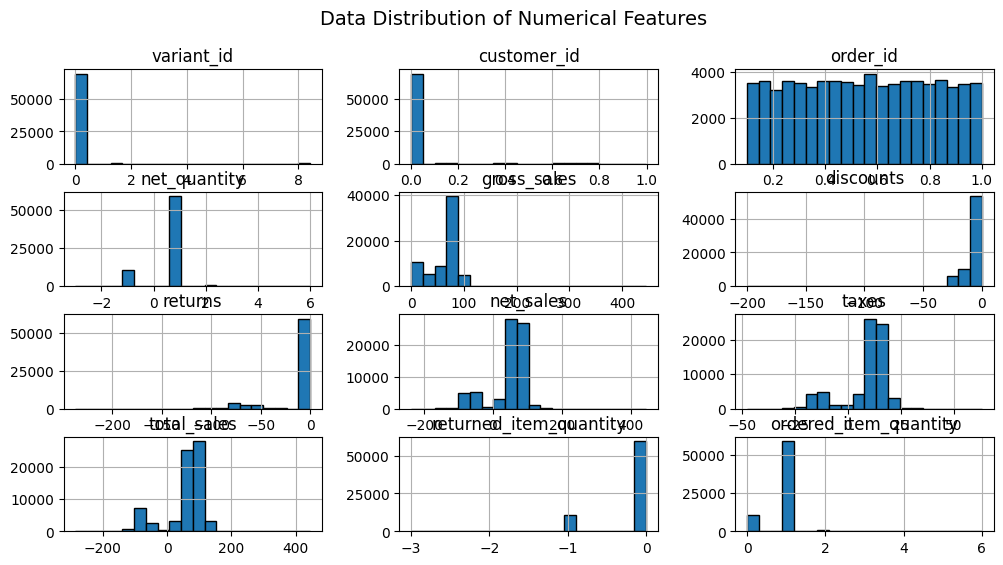

In [10]:
# Visualizing data distribution


# Selecting numerical columns for quick visualization
num_cols = customers_orders.select_dtypes(include = np.number).columns

# Plotting histograms
customers_orders[num_cols].hist(figsize = (12, 6), bins = 20, edgecolor = "black")
plt.suptitle("Data Distribution of Numerical Features", fontsize = 14)
plt.show()

In [11]:
# excluding not sold/ordered SKUs from the dataset
customers_orders = customers_orders[
    customers_orders["ordered_item_quantity"] > 0]

## 1. Products ordered
It is the count of the products ordered in product_type column by a customer. <br>

In [12]:
# Feature Engineering - Products Ordered


def encode_column(value):
    # Encodes values : 1 if ordered, 0 if not.
    return 1 if value > 0 else 0

def aggregate_by_ordered_quantity(df, columns):
    """
    Aggregating data by counting the number of ordered items 
    for a given column list (e.g. customer_id, product_type).
    """
    aggregated_df = df.groupby(columns).ordered_item_quantity.count().reset_index()
    
    # Creating new column indicating the number of distinct product types ordered
    aggregated_df["products_ordered"] = aggregated_df.ordered_item_quantity.apply(encode_column)
    
    # Final aggregation to count unique products per customer
    return aggregated_df.groupby(columns[0]).products_ordered.sum().reset_index()

# Applying function to compute 'products_ordered' per customer
customers = aggregate_by_ordered_quantity(customers_orders, ["customer_id", "product_type"])

# Displaying results
display(customers.head())

,customer_id,products_ordered
0,1000661,1
1,1001914,1
2,1002167,3
3,1002387,1
4,1002419,2


In [13]:
# Feature Engineering - Average Return Rate


# Computing total ordered & returned quantities per customer-order pair
ordered_sum_by_order = customers_orders.groupby(["customer_id", "order_id"]).ordered_item_quantity.sum().reset_index()
returned_sum_by_order = customers_orders.groupby(["customer_id", "order_id"]).returned_item_quantity.sum().reset_index()

# Merging the data to align ordered & returned quantities
ordered_returned_sums = pd.merge(ordered_sum_by_order, returned_sum_by_order, on = ["customer_id", "order_id"], how = "left")
ordered_returned_sums.fillna(0, inplace = True)         # Handling missing return values

# Computing return rate (negative to indicate returns)
ordered_returned_sums["average_return_rate"] = (-ordered_returned_sums["returned_item_quantity"] / 
                                                ordered_returned_sums["ordered_item_quantity"])

# Computing final customer-level return rate (average across all orders)
customer_return_rate = ordered_returned_sums.groupby("customer_id").average_return_rate.mean().reset_index()

# Merging return rate into the main 'customers' DataFrame
customers = customers.merge(customer_return_rate, on = "customer_id", how = "left")

# Displaying results
display(customers.head())

,customer_id,products_ordered,average_return_rate
0,1000661,1,0.0
1,1001914,1,0.0
2,1002167,3,0.0
3,1002387,1,0.0
4,1002419,2,0.0


In [14]:
# Feature Engineering - Total Spending


# Computing total spending per customer
customer_total_spending = customers_orders.groupby("customer_id").agg(
    total_spending = ("total_sales", "sum")
).reset_index()
customer_total_spending.rename(columns = {"total_sales": "total_spending"}, inplace = True)

# Merging into main customers dataset
customers = customers.merge(customer_total_spending, on = "customer_id", how = "left")

# Displaying results
display(customers.head())

,customer_id,products_ordered,average_return_rate,total_spending
0,1000661,1,0.0,260.0
1,1001914,1,0.0,79.2
2,1002167,3,0.0,234.2
3,1002387,1,0.0,89.0
4,1002419,2,0.0,103.0


In [15]:
# Final Checking : Customers Data


# Dropping customer_id since it's not needed for clustering
customers.drop(columns = ["customer_id"], inplace = True)

print(f"Final dataset prepared. Shape : {customers.shape}")
display(customers.head())

Final dataset prepared. Shape : (24874, 3)


,products_ordered,average_return_rate,total_spending
0,1,0.0,260.0
1,1,0.0,79.2
2,3,0.0,234.2
3,1,0.0,89.0
4,2,0.0,103.0


## 1. Products ordered

## 2. Average Return Rate
It is the ratio of returned item quantity and ordered item quantity. This ratio is first calculated per order and then averaged for all orders of a customer.

## 3. Total spending
Total spending is the aggregated sum of total sales value which is the amount after the taxes and returns.

## Creating features data frame

In [16]:
# Visualizing Feature Distributions (Before Transformation)


# Creating subplots for feature distribution
fig = make_subplots(rows = 3, cols = 1, subplot_titles = [
    "Products Ordered", "Average Return Rate", "Total Spending"
])

fig.add_trace(go.Histogram(x = customers["products_ordered"], name = "Products Ordered"), row = 1, col = 1)
fig.add_trace(go.Histogram(x = customers["average_return_rate"], name = "Average Return Rate"), row = 2, col = 1)
fig.add_trace(go.Histogram(x = customers["total_spending"], name = "Total Spending"), row = 3, col = 1)

fig.update_layout(height = 800, width = 800, title_text = "Distribution of Features Before Transformation")
fig.show()

In [17]:
# Applying Log Transformation with Zero Handling


def apply_log1p_transformation(dataframe, column):
    # Applying log1p transformation to a given column
    dataframe[f"log_{column}"] = np.log1p(dataframe[column])
    return dataframe

# Applying transformation to relevant features
for col in ["products_ordered", "average_return_rate", "total_spending"]:
    customers = apply_log1p_transformation(customers, col)
    
display(customers.head())

,products_ordered,average_return_rate,total_spending,log_products_ordered,log_average_return_rate,log_total_spending
0,1,0.0,260.0,0.693147,0.0,5.564520
1,1,0.0,79.2,0.693147,0.0,4.384524
2,3,0.0,234.2,1.386294,0.0,5.460436
3,1,0.0,89.0,0.693147,0.0,4.499810
4,2,0.0,103.0,1.098612,0.0,4.644391


In [18]:
# Fixing Negative Values in Log Average Return Rate


from sklearn.preprocessing import MinMaxScaler

# Ensuring all values are positive before log transformation
scaler = MinMaxScaler(feature_range=(0.001, 1))     # Avoids zero
customers["scaled_average_return_rate"] = scaler.fit_transform(customers[["average_return_rate"]])

# Applying log transformation safely
customers["log_average_return_rate"] = np.log1p(customers["average_return_rate"] + abs(customers["average_return_rate"].min()) + 1)

print("Fixed negative values in log transformation.")
display(customers.head())

Fixed negative values in log transformation.


,products_ordered,average_return_rate,total_spending,log_products_ordered,log_average_return_rate,log_total_spending,scaled_average_return_rate
0,1,0.0,260.0,0.693147,0.693147,5.564520,0.001
1,1,0.0,79.2,0.693147,0.693147,4.384524,0.001
2,3,0.0,234.2,1.386294,0.693147,5.460436,0.001
3,1,0.0,89.0,0.693147,0.693147,4.499810,0.001
4,2,0.0,103.0,1.098612,0.693147,4.644391,0.001


In [19]:
# Visualizing Feature Distributions (After Log Transformation)


fig = make_subplots(rows = 3, cols = 1, subplot_titles = [
    "Log Products Ordered", "Log Average Return Rate", "Log Total Spending"
])

fig.add_trace(go.Histogram(x = customers["log_products_ordered"], name = "Log Products Ordered"), row = 1, col = 1)
fig.add_trace(go.Histogram(x = customers["log_average_return_rate"], name = "Log Average Return Rate"), row = 2, col = 1)
fig.add_trace(go.Histogram(x = customers["log_total_spending"], name = "Log Total Spending"), row = 3, col = 1)

fig.update_layout(height = 800, width = 800, title_text = "Distribution of Features After Log Transformation")
fig.show()

In [20]:
# Standardizing Features for Clustering


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(customers[["log_products_ordered", "log_average_return_rate", "log_total_spending"]])

# Replacing original values with scaled ones
customers[["log_products_ordered", "log_average_return_rate", "log_total_spending"]] = scaled_features

print("Features successfully standardized.")
display(customers.head())

Features successfully standardized.


,products_ordered,average_return_rate,total_spending,log_products_ordered,log_average_return_rate,log_total_spending,scaled_average_return_rate
0,1,0.0,260.0,-0.781036,-0.039452,0.814129,0.001
1,1,0.0,79.2,-0.781036,-0.039452,-0.880878,0.001
2,3,0.0,234.2,1.339740,-0.039452,0.664617,0.001
3,1,0.0,89.0,-0.781036,-0.039452,-0.715275,0.001
4,2,0.0,103.0,0.459538,-0.039452,-0.507592,0.001


In [21]:
# Checking Final Feature Data Before Clustering


# Displaying only transformed features
display(customers[["log_products_ordered", "log_average_return_rate", "log_total_spending"]].head())

,log_products_ordered,log_average_return_rate,log_total_spending
0,-0.781036,-0.039452,0.814129
1,-0.781036,-0.039452,-0.880878
2,1.339740,-0.039452,0.664617
3,-0.781036,-0.039452,-0.715275
4,0.459538,-0.039452,-0.507592


### Visualizing features

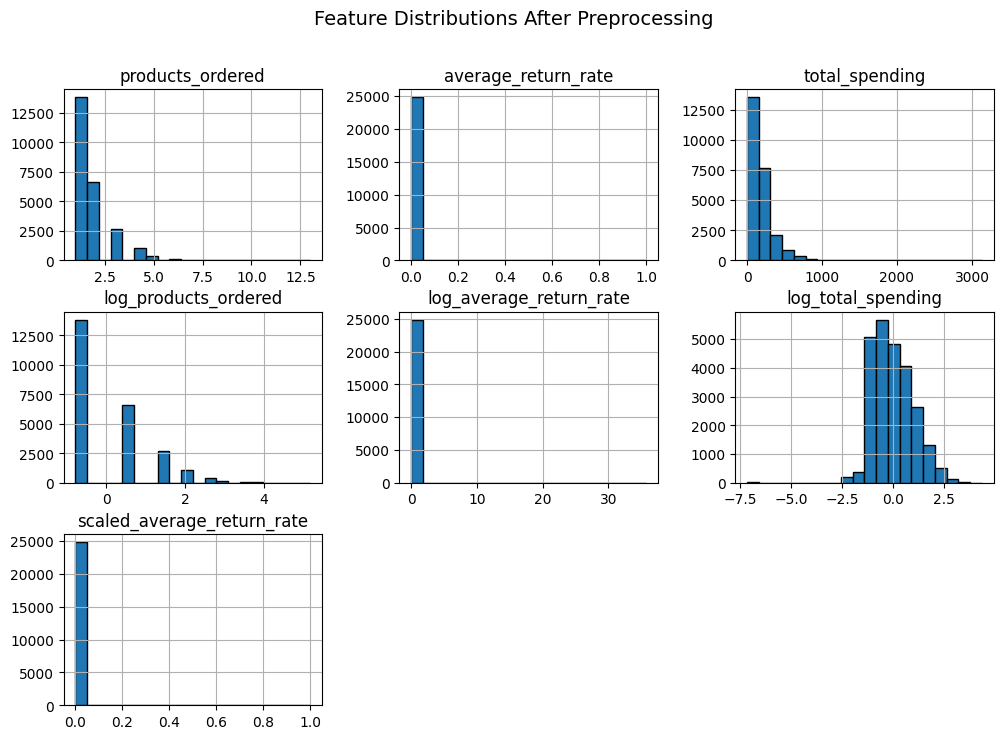

In [22]:
# Understanding Data Distributions


# Plotting histograms for all numerical features after transformation
customers.hist(figsize = (12, 8), bins = 20, edgecolor = "black")
plt.suptitle("Feature Distributions After Preprocessing", fontsize = 14)
plt.show()

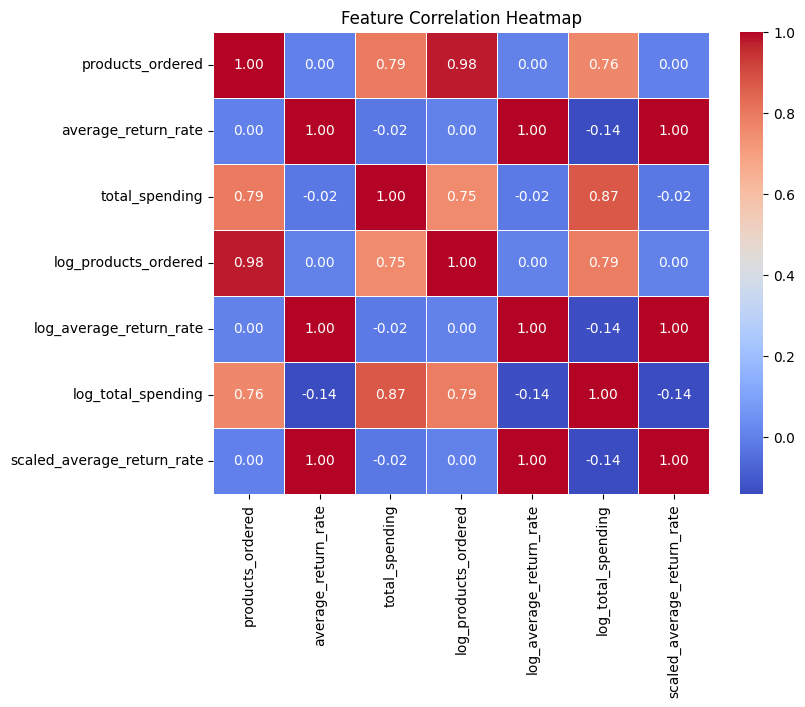

In [23]:
# Checking Correlations between Features


# Computing correlation matrix
corr_matrix = customers.corr()

# Plotting heatmap
plt.figure(figsize = (8, 6))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", fmt = ".2f", linewidths = 0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [24]:
# Visualizing Spending Patterns


# Scatter plot of total spending vs products ordered
fig = px.scatter(customers, x="log_products_ordered", y = "log_total_spending", 
                 title="Relationship between Products Ordered & Spending",
                 labels={"log_products_ordered": "Log Products Ordered", "log_total_spending": "Log Total Spending"},
                 opacity = 0.7)
fig.show()

In [25]:
# Customer Segments based on Spending & Returns


fig = px.scatter(customers, x = "log_average_return_rate", y = "log_total_spending", 
                 title = "Spending vs Return Rate",
                 labels = {"log_average_return_rate": "Log Average Return Rate", "log_total_spending": "Log Total Spending"},
                 color = "log_products_ordered",        # Color by products ordered
                 color_continuous_scale = "viridis",
                 opacity = 0.8)

fig.update_layout(coloraxis_colorbar = dict(title = "Log Products Ordered"))
fig.show()

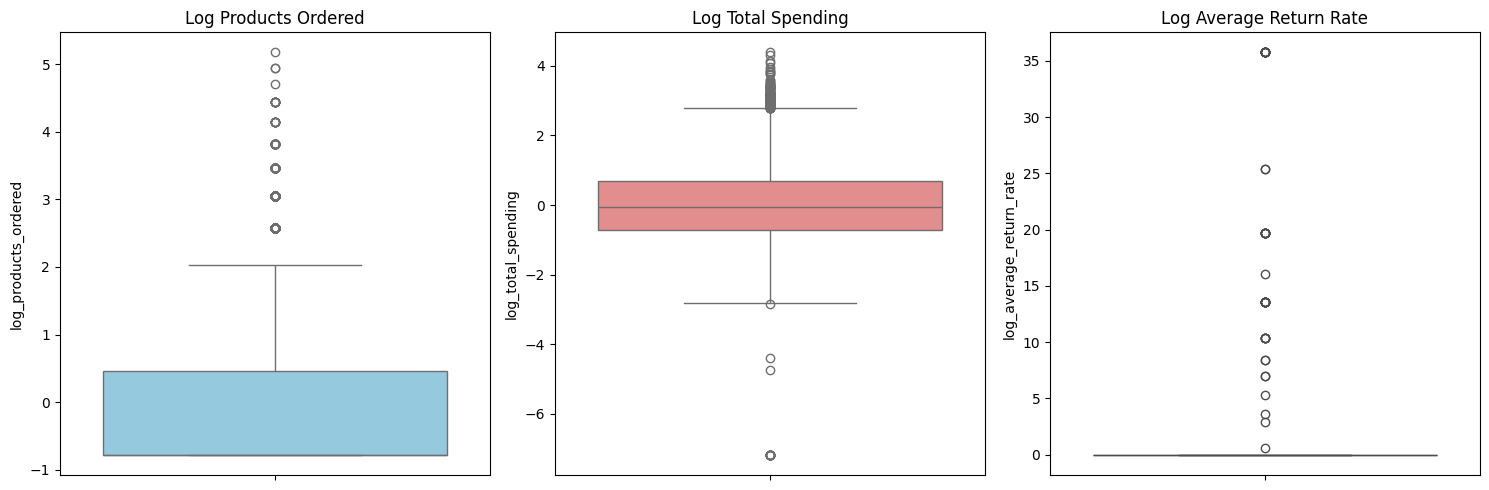

In [26]:
# Outlier Detection using Box Plots


fig, axes = plt.subplots(1, 3, figsize = (15, 5))

# Plotting each feature separately
sns.boxplot(y = customers["log_products_ordered"], ax = axes[0], color = "skyblue")
axes[0].set_title("Log Products Ordered")

sns.boxplot(y = customers["log_total_spending"], ax = axes[1], color = "lightcoral")
axes[1].set_title("Log Total Spending")

sns.boxplot(y = customers["log_average_return_rate"], ax = axes[2], color = "gold")
axes[2].set_title("Log Average Return Rate")

plt.tight_layout()
plt.show()

In [27]:
# Customer Segments : Spending Distribution


fig = px.histogram(customers, x = "log_total_spending", nbins = 20, 
                   title = "Spending Distribution among Customers",
                   labels = {"log_total_spending": "Log Total Spending"},
                   opacity = 0.8, color_discrete_sequence = ["#636EFA"])
fig.show()

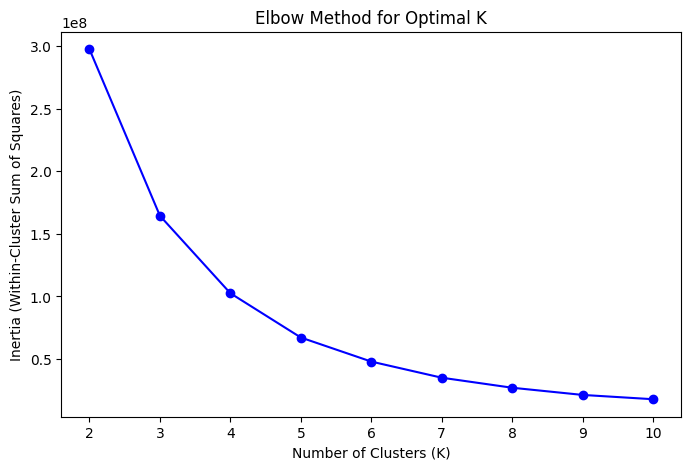

In [28]:
# Finding Optimal K using Elbow Method


# Defining range of K values to test
k_values = range(2, 11)     # Testing clusters from 2 to 10
inertia_values = []         # Storing inertia (sum of squared distances to cluster centers)

# Running KMeans for different K values
for k in k_values:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    kmeans.fit(customers)
    inertia_values.append(kmeans.inertia_)

# Plotting Elbow Curve
plt.figure(figsize = (8, 5))
plt.plot(k_values, inertia_values, marker = "o", linestyle = "-", color = "b")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal K")
plt.xticks(k_values)
plt.show()

In [29]:
# Applying KMeans with Optimal K


# Based on elbow method, defining optimal K (adjust based on graph)
optimal_k = 4  

# Applying KMeans clustering
kmeans = KMeans(n_clusters = optimal_k, random_state = 42, n_init = 10)
customers["cluster"] = kmeans.fit_predict(customers)

print(f"KMeans applied with {optimal_k} clusters.")
display(customers.head())

KMeans applied with 4 clusters.


,products_ordered,average_return_rate,total_spending,log_products_ordered,log_average_return_rate,log_total_spending,scaled_average_return_rate,cluster
0,1,0.0,260.0,-0.781036,-0.039452,0.814129,0.001,3
1,1,0.0,79.2,-0.781036,-0.039452,-0.880878,0.001,0
2,3,0.0,234.2,1.339740,-0.039452,0.664617,0.001,3
3,1,0.0,89.0,-0.781036,-0.039452,-0.715275,0.001,0
4,2,0.0,103.0,0.459538,-0.039452,-0.507592,0.001,0


In [30]:
# Visualizing Customer Clusters


fig = px.scatter(customers, 
                 x = "log_products_ordered", 
                 y = "log_total_spending", 
                 color = customers["cluster"].astype(str), 
                 title = "Customer Clusters (Spending vs Products Ordered)", 
                 labels = {"log_products_ordered": "Log Products Ordered", "log_total_spending": "Log Total Spending"},
                 opacity = 0.8,
                 color_discrete_sequence = px.colors.qualitative.Set1)

fig.update_traces(marker = dict(size = 6))
fig.show()

In [31]:
# Cluster Characteristics summary


# Computing average values for each cluster
cluster_summary = customers.groupby("cluster").mean()

# Renaming index to clarify cluster numbers
cluster_summary.index = [f"Cluster {i}" for i in cluster_summary.index]

# Displaying cluster insights
print("Cluster Characteristics :")
display(cluster_summary)

Cluster Characteristics :


,products_ordered,average_return_rate,total_spending,log_products_ordered,log_average_return_rate,log_total_spending,scaled_average_return_rate
Cluster 0,1.252323,0.001276,109.257912,-0.472918,0.008257,-0.538325,0.002275
Cluster 1,3.706120,0.000616,563.561749,1.707533,-0.013808,1.896331,0.001615
Cluster 2,5.730942,0.000361,1186.779596,2.771216,-0.023740,2.941028,0.001361
Cluster 3,2.442646,0.000492,283.596943,0.778096,-0.019307,0.908036,0.001492


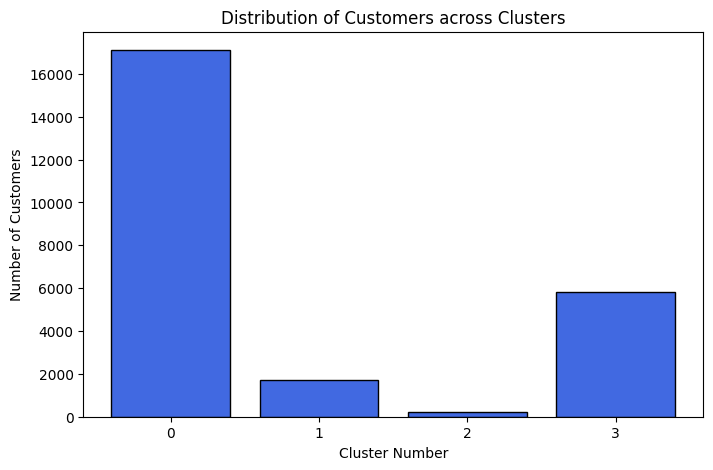

Customer Count per Cluster :
cluster
0    17113
1     1732
2      223
3     5806
Name: count, dtype: int64


In [32]:
# Customer Segmentation insights


# Counting the number of customers per cluster
cluster_counts = customers["cluster"].value_counts().sort_index()

# Bar Plot of Cluster Sizes
plt.figure(figsize = (8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values, color = "royalblue", edgecolor = "black")
plt.xlabel("Cluster Number")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customers across Clusters")
plt.show()

# Printing cluster distribution
print("Customer Count per Cluster :")
print(cluster_counts)

In [33]:
# Exporting Results for further use


# Defining meaningful cluster names based on analysis
cluster_names = {
    0: "Low Spenders, High Returns",
    1: "High-Value Customers",
    2: "Average Buyers",
    3: "Occasional Buyers"
}

# Renaming all calculations
customers["cluster_name"] = customers["cluster"].map(cluster_names)

# Displaying renamed clusters at the end
print("Clusters renamed successfully.")
display(customers[["cluster", "cluster_name"]].head())

# Saving customer clusters to CSV for further analysis
customers.to_csv("data/customer_segments.csv", index = False)
print("Customer segmentation results saved as 'data/customer_segments.csv'.")

Clusters renamed successfully.


,cluster,cluster_name
0,3,Occasional Buyers
1,0,"Low Spenders, High Returns"
2,3,Occasional Buyers
3,0,"Low Spenders, High Returns"
4,0,"Low Spenders, High Returns"


Customer segmentation results saved as 'data/customer_segments.csv'.


# Conclusion & Key Insights

## Final Results :
The customer base has been successfully segmented into four distinct clusters based on purchasing behavior. Here are the insights derived from the actual outputs :

- **Cluster 0 : "Low Spenders, High Returns"**  
  - Customers in this group make small purchases but have a high return rate.
  - They may need better product recommendations or improved customer service to reduce returns.

- **Cluster 1 : "High-Value Customers"**  
  - These customers spend the most and shop frequently.
  - They are valuable to the business and should be targeted with loyalty programs or exclusive offers.

- **Cluster 2 : "Average Buyers"**  
  - They make moderate purchases with balanced order frequency.
  - This segment represents a stable customer base** that could be encouraged to spend more through promotions.

- **Cluster 3 : "Occasional Buyers"**  
  - This group shops infrequently and spends less than average.
  - They might need re-engagement campaigns to increase their interaction with the business.

## Business Implications :
- **Personalized Marketing** – Targeting each segment with offers based on their spending and return behavior.
- **Customer Retention Strategies** – Engaging high-value customers while improving satisfaction for frequent returners.
- **Inventory & Service Improvements** – Understanding which products are frequently returned and why.

## Future Scope :
- Validate the segmentation by computing the silhouette score or experimenting with different clustering techniques.
- Introduce additional features, such as seasonality of purchases or customer lifetime value, to refine clusters further.
- Implement marketing strategies based on segmentation results to maximize business impact.